In [1]:
%pip install langchain_community tiktoken langchainhub chromadb langchain beautifulsoup4 langchain-text-splitters pathlib pypdf scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -U langchain-ollama
# pour telecharger les modeles : terminal : ollama pull llama3.1:8b et  ollama pull nomic-embed-text-v2-moe

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] =   "your_api_key_here"  # Replace with your actual API key

# Indexing and retrieval
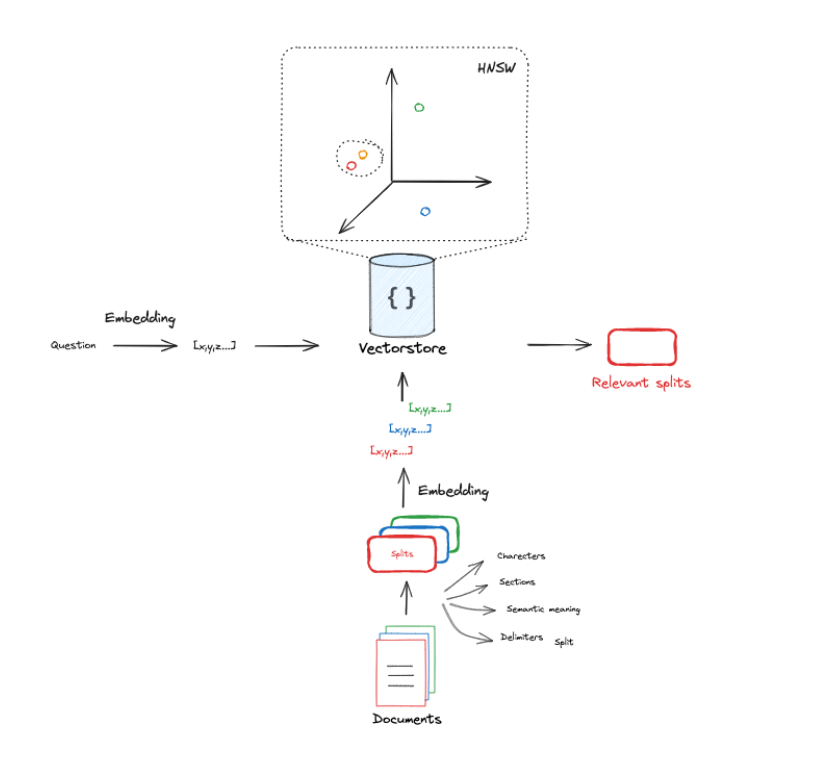

In [21]:
from pathlib import Path

import bs4
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_ollama import ChatOllama, OllamaEmbeddings



#### INDEXING ####

# Load Documents
PDF_DIR = Path(r"C:\Users\barta\Documents\cours\ML_IMT\bid_data\projet_loi\PDF")
N_PDFS = None  # mets None pour tous les PDF

pdf_files = sorted(PDF_DIR.glob("*.pdf"))[:N_PDFS]
print(f"{len(pdf_files)} PDF chargés sur {len(list(PDF_DIR.glob('*.pdf')))} disponibles")

# Load Documents
docs = []
for pdf in pdf_files:
    docs.extend(PyPDFLoader(str(pdf)).load())  # un Document par page


49 PDF chargés sur 49 disponibles


In [5]:
import json

ids = []
questions = []
answerable = []
expected = []
keywords = []

with open("questions.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        ids.append(d["id"])
        questions.append(d["question"])
        answerable.append(d["answerable"])
        expected.append(d["expected"])
        keywords.append(d["keywords"])

print(len(questions), "questions chargées")
print("Exemple de question :", questions[0])
print("Exemple de réponse attendue :", expected[0])
print("Exemple de réponse attendue :", answerable[0])
print("Exemple de mots-clés :", keywords[0])

25 questions chargées
Exemple de question : ¿Que congresista o representante propone la creacion del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
Exemple de réponse attendue : [{'source': 'gaceta_1313_9cb92c92d3', 'pages': [1, 2]}]
Exemple de réponse attendue : True
Exemple de mots-clés : ['David Alejandro Toro Ramírez', 'Yolanda Silva Romero']


# sparse embedding 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer(strip_accents="unicode", lowercase=True)
X = vectorizer.fit_transform([doc.page_content for doc in docs])

question = questions[0]  # "Cual es las medidas de protección para los actores en Colombia?"
question_vector = vectorizer.transform([question])

# Score de chaque document vis-à-vis de la question
scores = cosine_similarity(question_vector, X).ravel()   # shape: (n_docs,)

# Top-k
k = 5
top_idx = np.argsort(scores)[::-1][:k]

for i in top_idx:
    print(f"Score: {scores[i]:.4f}")
    print(docs[i].metadata)
    print(docs[i].page_content[:300], "\n")

# Le meilleur document seul
best_doc = docs[top_idx[0]]
answerable0 = answerable[0]
expected0 = expected[0]


Score: 0.3916
{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.5 (Macintosh)', 'creationdate': '2026-09-22T12:13:13-05:00', 'moddate': '2026-09-22T12:13:17-05:00', 'trapped': '/False', 'source': 'C:\\Users\\barta\\Documents\\cours\\ML_IMT\\bid_data\\projet_loi\\PDF\\gaceta_1313_9cb92c92d3.pdf', 'total_pages': 24, 'page': 0, 'page_label': '1'}
DIRECTORES: MIGUEL ÁNGEL SÁNCHEZ VÁSQUEZ
SECRETARIO  GENERAL  DE  LA  CÁMARA
www.camara.gov.co 
DIEGO ALEJANDRO GONZÁLEZ GONZÁLEZ
SECRETARIO  GENERAL  DEL  SENADO 
www.secretariasenado.gov.co 
(Artículo 36,  Ley 5ª de 1992)
IMPRENTA   NACIONAL   DE   COLOMBIA
www.imprenta.gov.co
SENADO Y CÁMARA
AÑO  

Score: 0.3659
{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.5 (Macintosh)', 'creationdate': '2026-09-22T12:13:13-05:00', 'moddate': '2026-09-22T12:13:17-05:00', 'trapped': '/False', 'source': 'C:\\Users\\barta\\Documents\\cours\\ML_IMT\\bid_data\\projet_loi\\PDF\\gaceta_1313_9cb92c92d3.pdf', 'total_pages': 2

# dense embedding 

In [7]:
# Split
text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=200)#chunk size according to token input of emb to correct
splits = text_splitter.split_documents(docs)


In [9]:


from tqdm import tqdm

embd = OllamaEmbeddings(model="nomic-embed-text-v2-moe:latest")

# nettoyage 
for s in splits:
    s.page_content = s.page_content.replace("\x00", "").strip()
splits = [s for s in splits if s.page_content]

# Vectorstore vide, puis ajout par lots
vectorstore = Chroma(embedding_function=embd, persist_directory="./chroma_db")  # ajoute persist_directory="./chroma_db" pour sauvegarder sur disque

BATCH = 32
for i in tqdm(range(0, len(splits), BATCH)):
    vectorstore.add_documents(splits[i:i+BATCH])

retriever = vectorstore.as_retriever(k=5)


100%|██████████| 522/522 [06:54<00:00,  1.26it/s]


In [10]:
retrieved = []
for doc in retriever.invoke(question[0]):
    retrieved.append(
        {
            "text": doc.page_content,
            "source": doc.metadata.get("source", "unknown"),
            "page": int(doc.metadata.get("page", 0))
        }
    )
for i in range(len(retrieved)):
    print(f"Retrieved texte : {retrieved[i]['text']} ")
    print(f"Retrieved source : {retrieved[i]['source']} ")
    print(f"Retrieved page : {retrieved[i]['page']}")


Retrieved texte : • ¿Qué controles impedirán que una reducción futura del encarcelamiento se convierta en un costo contractual para el Estado?
• ¿Qué indicadores de derechos humanos, resocialización y reincidencia tendrán igual o mayor peso que los indicadores
financieros?UTP | CONCEPTO TÉCNICO-JURÍDICO Y DE POLÍTICA PÚBLICA PL 092 DE 2026 SENADO
Documento para deliberación legislativa - Septiembre de 2026 Página 11
• ¿Alguna modificación durante el trámite regula elementos estructurales de derechos fundamentales y activa reserva estatutaria? 
Retrieved source : C:\Users\barta\Documents\cours\ML_IMT\bid_data\projet_loi\PDF\gaceta_1345_aeffdef335.pdf 
Retrieved page : 4
Retrieved texte : • ¿Qué controles impedirán que una reducción futura del encarcelamiento se convierta en un costo contractual para el Estado?
• ¿Qué indicadores de derechos humanos, resocialización y reincidencia tendrán igual o mayor peso que los indicadores
financieros?UTP | CONCEPTO TÉCNICO-JURÍDICO Y DE POLÍTICA PÚB

In [ ]:
print(len(embd.embed_query("test")))

768


# generation 
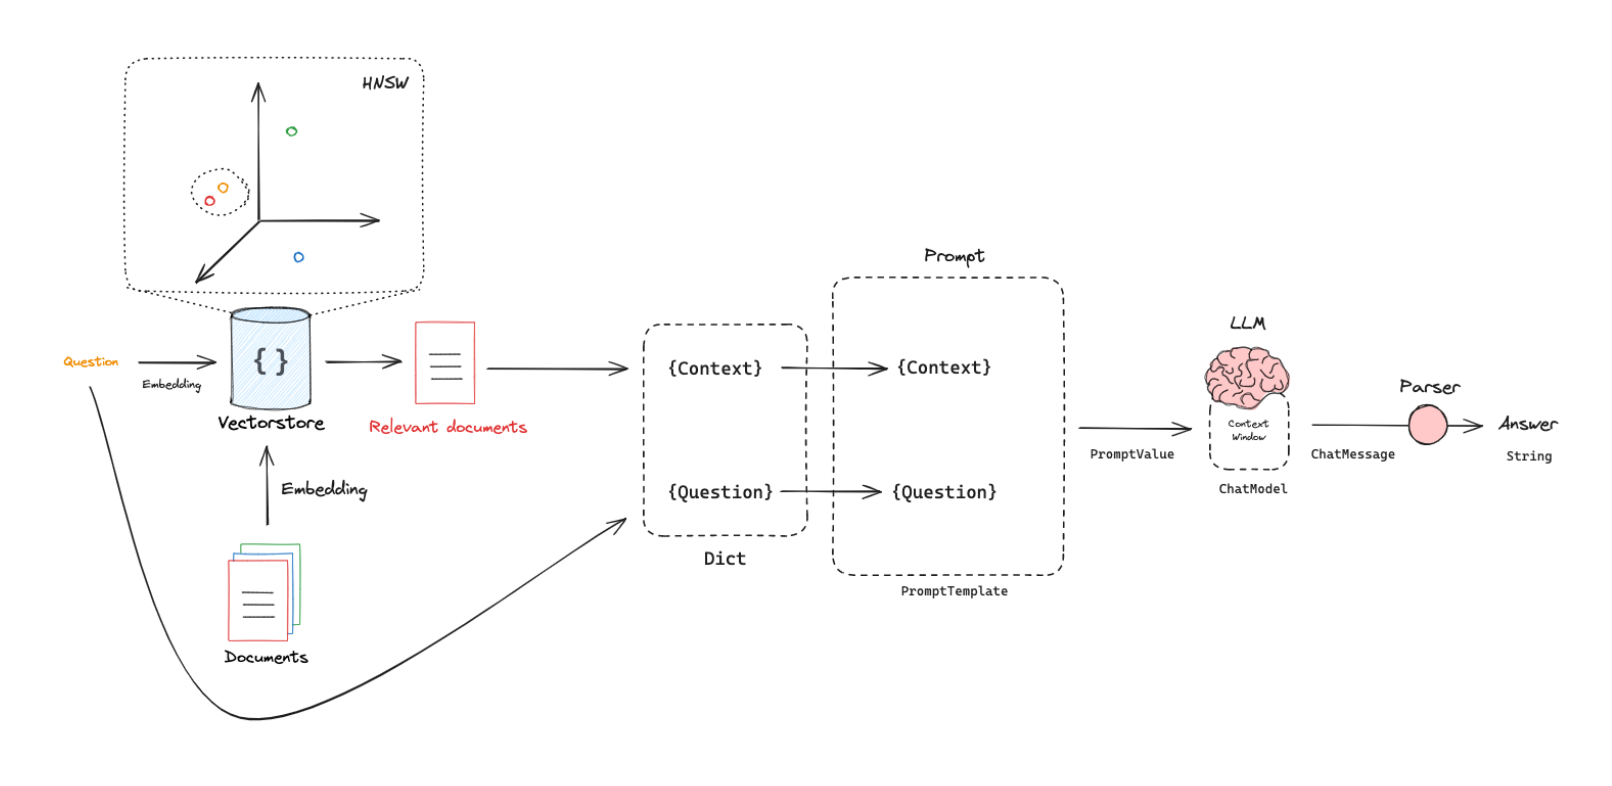

In [11]:
# Prompt
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
    IMPORTANT RULE : at the end of your answer, you must cite the source(s) used and the exact page number in the following format:
Source: <file_name>, Page: <number>
Question: {question}
Context: {context}
Detailed Answer with formated response:"""
)
# LLM
llm = ChatOllama(model="llama3.1:8b", temperature=0)

# Post-processing for source and page number formatting
import os

def format_docs_with_metadata(docs):
    formatted = []
    for doc in docs:
        # Récupération propre de la source (nom de fichier uniquement) et de la page
        raw_source = doc.metadata.get("source", "Inconnue")
        source_name = os.path.basename(raw_source)

        # PyPDF indexe les pages à partir de 0, on ajoute souvent 1 pour correspondre à la pagination réelle du document
        page_num = doc.metadata.get("page", 0) + 1

        content = doc.page_content.strip()

        # Format structuré injecté dans le contexte
        formatted_chunk = (
            f"[Source: {source_name} | Page: {page_num}]\n" f"{content}"
        )
        formatted.append(formatted_chunk)

    return "\n\n---\n\n".join(formatted)

# Chain
rag_chain = (
    {"context": retriever | format_docs_with_metadata, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Question
print("Question:", questions[0])
print(rag_chain.invoke(questions[0]))
print(expected0)
print(answerable0)
print(keywords[0])

for question in questions:
    print("Question:", question)
    print(rag_chain.invoke(question))
    print("Expected:", expected[questions.index(question)])
    print("Answerable:", answerable[questions.index(question)])
    print("Keywords:", keywords[questions.index(question)])
    print("\n" + "="*50 + "\n")

Question: ¿Que congresista o representante propone la creacion del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
The congresista or representative who proposes the creation of the Fondo Nacional de Reparación Histórica is not specified in the provided context. However, the context mentions that the Proyecto de Ley número 151 de 2025 Cámara is being discussed in the Cámara de Representantes.

Source: gaceta_1313_9cb92c92d3.pdf, Page: 16
[{'source': 'gaceta_1313_9cb92c92d3', 'pages': [1, 2]}]
True
['David Alejandro Toro Ramírez', 'Yolanda Silva Romero']
Question: ¿Que congresista o representante propone la creacion del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
The congresista or representative who proposes the creation of the Fondo Nacional de Reparación Histórica is not specified in the provided context. However, the context mentions that the Proyecto de Ley número 151 de 2025 Cám

In [12]:
#token counting can be useful to check if the input is too long for the model, or to estimate costs of using a model.
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(questions[0], "cl100k_base")

38

# multi query

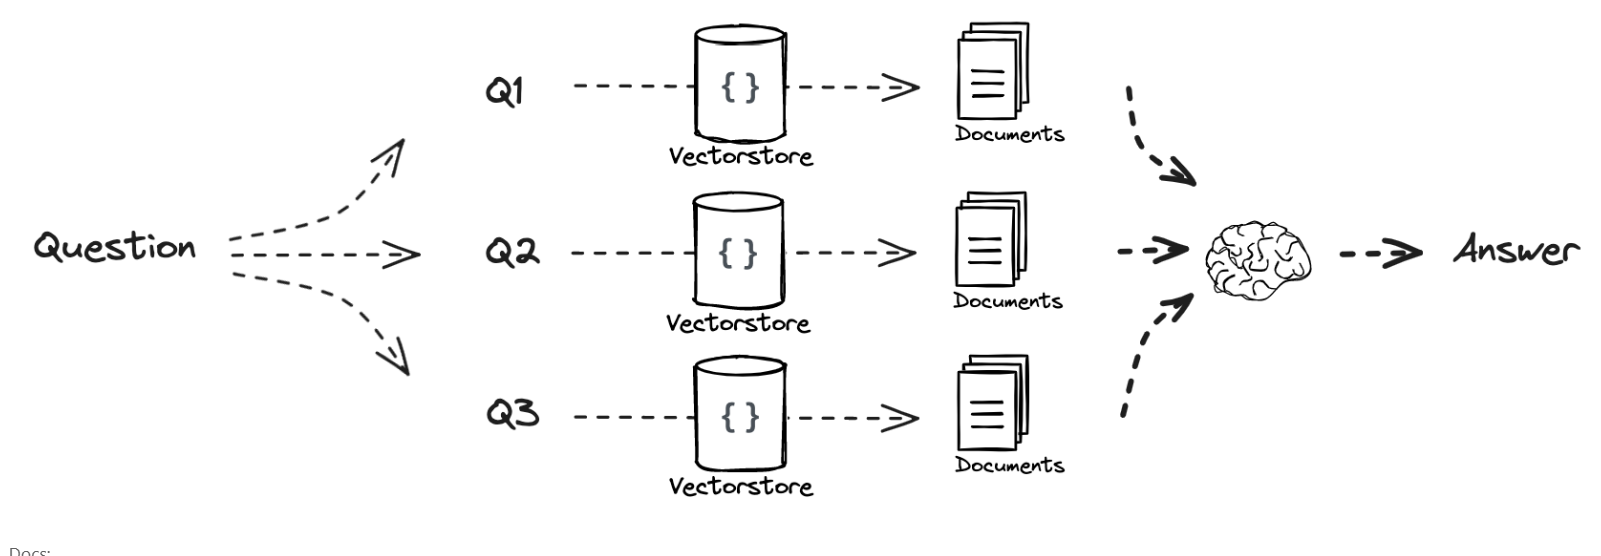

In [13]:
from langchain_core.prompts import ChatPromptTemplate

# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""
prompt_perspectives = ChatPromptTemplate.from_template(template)

from langchain_core.output_parsers import StrOutputParser

generate_queries = (
    prompt_perspectives 
    | ChatOllama(model="llama3.1:8b", temperature=0) 
    | StrOutputParser() 
    | (lambda x: x.split("\n"))
)

In [22]:
from langchain_core.load import dumps, loads
from langchain_core.documents import Document

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    unique_docs = list(set(flattened_docs))
    return [loads(doc, allowed_objects=[Document]) for doc in unique_docs]

# Retrieve
retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs0 = retrieval_chain.invoke({"question":questions[0]})
len(docs0)
# 44 unique docs relate to question, but some are not relevant. We can filter them by using a LLM to check if the doc is relevant to the question.

44

In [25]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

# RAG

llm = ChatOllama(model="llama3.1:8b", temperature=0)

from langchain_core.load import dumps, loads
from langchain_core.documents import Document

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    unique_docs = list(set(flattened_docs))
    return [loads(doc, allowed_objects=[Document]) for doc in unique_docs]

# Retrieve
retrieval_chain = generate_queries | retriever.map() | get_unique_union

final_rag_chain = (
    {"context": retrieval_chain | format_docs_with_metadata, 
     "question": itemgetter("question")} 
    | prompt
    | llm
    | StrOutputParser()
)
for question, exp, ans, kw in zip(questions, expected, answerable, keywords):
    print("Question:", question)
    print(final_rag_chain.invoke({"question": question}))
    print("Expected:", exp)
    print("Answerable:", ans)
    print("Keywords:", kw)
    print("\n" + "=" * 50 + "\n")

Question: ¿Que congresista o representante propone la creacion del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
It appears that you have provided multiple sources with similar content. I will provide a detailed answer based on the first source: [Source: gaceta_1313_9cb92c92d3.pdf | Page: 16]

**Summary:**

The document discusses the creation of the Fondo Nacional de Reparación Histórica (National Historical Reparation Fund) through the Proyecto de Ley número 151 de 2025 Cámara. The fund aims to address the effects and consequences of colonialism, the colonial and slave systems, structural and systemic racism, and racial discrimination that impact indigenous peoples in the country.

**Key Points:**

1. The Proyecto de Ley número 151 de 2025 Cámara was presented to the Comisión Sexta de la Cámara de Representantes.
2. The fund aims to superar los efectos y consecuencias del colonialismo, el sistema colonial y esclavista, el racismo est

KeyboardInterrupt: 

## HyDE

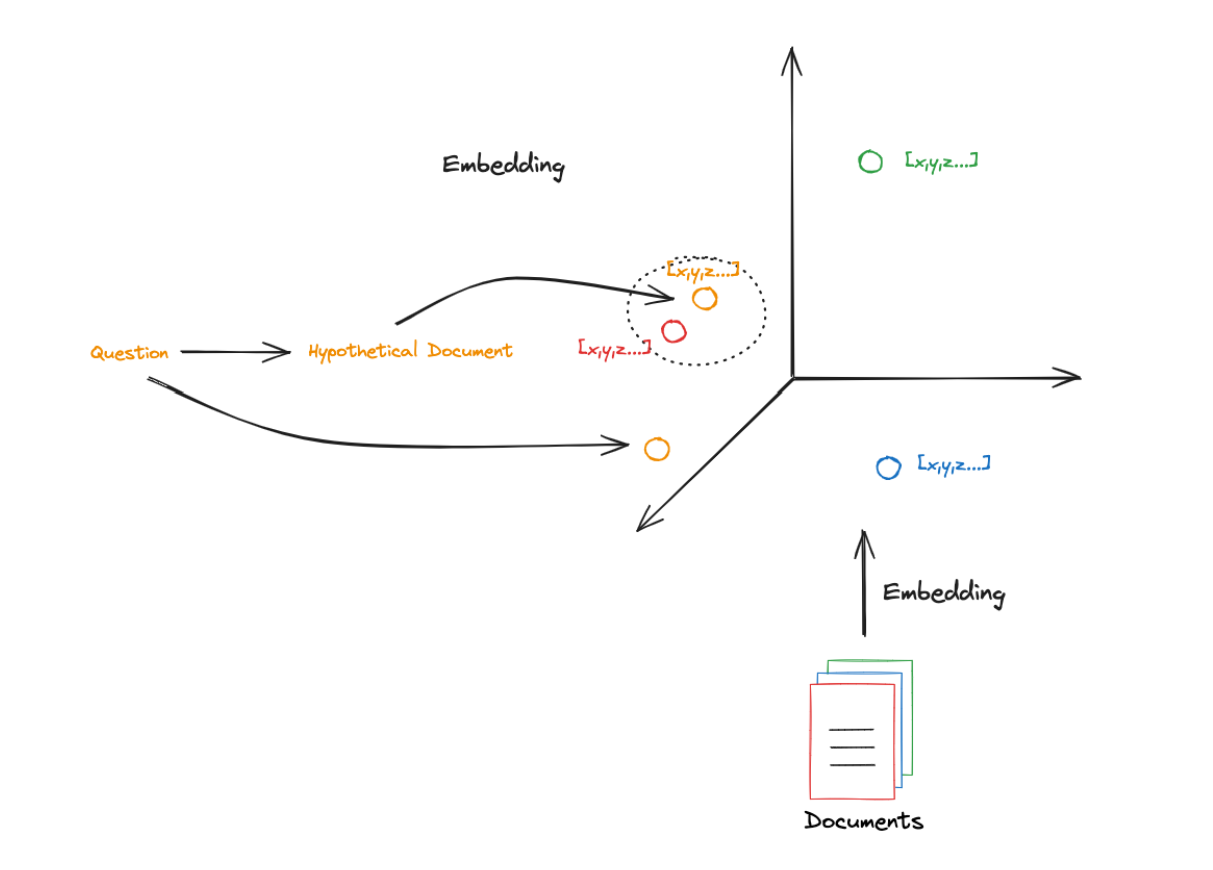
Docs: 

* https://github.com/langchain-ai/langchain/blob/master/cookbook/hypothetical_document_embeddings.ipynb

Paper:

* https://arxiv.org/abs/2212.10496

In [32]:
from operator import itemgetter
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatOllama(model="llama3.1:8b", temperature=0)

template = """Please write a juridical paper passage in spanish to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

generate_docs_for_retrieval = prompt_hyde | llm | StrOutputParser()

retrieval_chain = (
    {"question": itemgetter("question")}
    | generate_docs_for_retrieval
    | retriever
    | format_docs_with_metadata
)

final_rag_chain = (
    {"context": retrieval_chain,
     "question": itemgetter("question")}
    | prompt
    | llm
    | StrOutputParser()
)

for question, exp, ans, kw in zip(questions, expected, answerable, keywords):
    print("Question:", question)
    print("Answer:", final_rag_chain.invoke({"question": question}))
    print("Expected:", exp)
    print("Answerable:", ans)
    print("Keywords:", kw)
    print("\n" + "=" * 50 + "\n")


Question: ¿Que congresista o representante propone la creacion del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
Answer: Lo siento, pero no hay información en el contexto proporcionado sobre quién propone la creación del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo. 

Source: gaceta_1333_8b1eec7bfc.pdf, Page: 5
Expected: [{'source': 'gaceta_1313_9cb92c92d3', 'pages': [1, 2]}]
Answerable: True
Keywords: ['David Alejandro Toro Ramírez', 'Yolanda Silva Romero']


Question: ¿Que normas del primer debate se decidieron resaltar para el segundo debate de la creación del Fondo Nacional de Reparación Histórica para superar los efectos y consecuencias del colonialismo?
Answer: Lo siento, pero no hay suficiente información en el contexto proporcionado para responder a la pregunta de manera precisa. No se mencionan específicamente las normas del primer debate que se decidieron resaltar para el s